In [ ]:
#random forest implementation here 
#using the LOSO method which I have heard is the standard for PAMPA2 

In [6]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils import shuffle

In [8]:
#first we need to take snapshots of the each data set with the sliding window 
def sliding_window_features(df, window_size=100, step=50):
    feature_cols = df.columns.drop("activityID")
    X, y = [], []
    
    for start in range(0, len(df) - window_size + 1, step):
        window = df.iloc[start:start + window_size]
      
        label = window["activityID"].mode()[0]
      
        features = []
        for col in feature_cols:
            features += [
                window[col].mean(),
                window[col].std(),
                window[col].min(),
                window[col].max(),
            ]
        
        X.append(features)
        y.append(label)
    
    return np.array(X), np.array(y)
  

In [ ]:
import os

for i in range(1, 9):
    globals()[f"data_{i}"] = pd.read_pickle(rf"/content/CPEN355_FinalProject/preprocessing/data/data_{i}.pkl")

X_all = {}
y_all = {}

for i in range(1, 9):
    df = globals()[f"data_{i}"]
    X, y = sliding_window_features(df, window_size=100, step=50)
    X_all[i] = X
    y_all[i] = y

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import shuffle

# random forest regressor model
results = {}

# Track predictions across ALL subjects for the global confusion matrix
global_y_true = []
global_y_pred = []

# LOSO cross-validation
for test_subject in range(1,9):
    x_train = np.vstack([X_all[i] for i in range(1,9) if i != test_subject])
    y_train = np.concatenate([y_all[i] for i in range(1,9) if i != test_subject])
    x_train, y_train = shuffle(x_train, y_train, random_state=50)

    model = RandomForestClassifier(n_estimators=100, random_state=50, n_jobs=-1)
    model.fit(x_train, y_train)
    y_pred = model.predict(X_all[test_subject])

    # Record predictions globally for the CM
    global_y_true.extend(y_all[test_subject])
    global_y_pred.extend(y_pred)

    acc = accuracy_score(y_all[test_subject], y_pred)
    mac_f1 = f1_score(y_all[test_subject], y_pred, average='macro')
    wt_f1 = f1_score(y_all[test_subject], y_pred, average='weighted')

    results[test_subject] = {
        "accuracy": acc,
        "macro_f1": mac_f1,
        "weighted_f1": wt_f1,
        "report": classification_report(y_all[test_subject], y_pred)
    }

    print(f"Subject {test_subject} (test) — Accuracy: {acc:.4f} | Macro F1: {mac_f1:.4f}")

print(f"\nMean LOSO Accuracy: {np.mean([r['accuracy'] for r in results.values()]):.4f}")

Subject 1 (test) — Accuracy: 0.8006 | Macro F1: 0.7787
Subject 2 (test) — Accuracy: 0.9494 | Macro F1: 0.9493
Subject 3 (test) — Accuracy: 0.9556 | Macro F1: 0.9564
Subject 4 (test) — Accuracy: 0.9540 | Macro F1: 0.9499
Subject 5 (test) — Accuracy: 0.9529 | Macro F1: 0.9472
Subject 6 (test) — Accuracy: 0.9292 | Macro F1: 0.9281
Subject 7 (test) — Accuracy: 0.9656 | Macro F1: 0.9607
Subject 8 (test) — Accuracy: 0.9666 | Macro F1: 0.9622

Mean LOSO Accuracy: 0.9342


=== Classification Report: Subject 1 ===
              precision    recall  f1-score   support

           1       0.96      0.98      0.97        49
           2       1.00      0.07      0.13        43
           3       0.48      0.70      0.57        40
           4       1.00      0.95      0.97        39
          12       0.96      0.90      0.93        29
          13       1.00      0.93      0.96        27
          16       0.87      0.95      0.91        42
          17       0.65      1.00      0.79        42

    accuracy                           0.80       311
   macro avg       0.87      0.81      0.78       311
weighted avg       0.86      0.80      0.77       311

=== Sample counts per activity ===
Activity        Subject 1   Mean (others)
1                      49            42.7
2                      43            42.1
3                      40            43.6
4                      39            53.3
12                     29            26.7
13                   

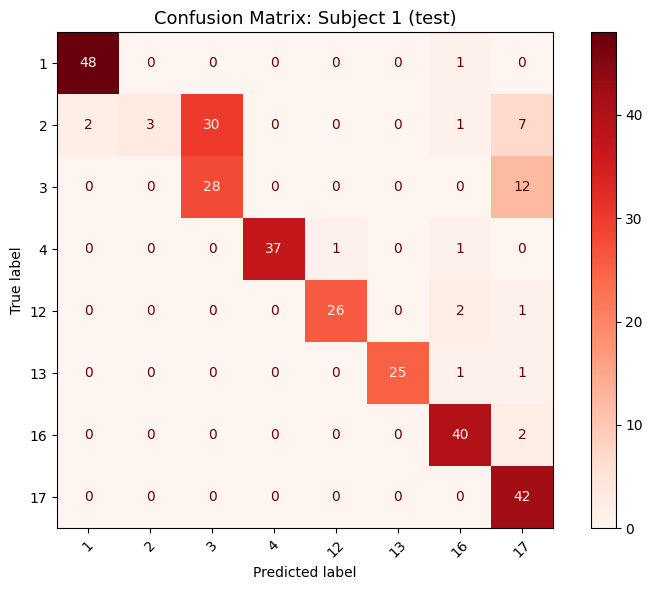

In [12]:
# claude wrote this code 


# --- Deep dive into Subject 1 ---
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Re-run Subject 1 fold to get predictions
x_train_s1 = np.vstack([X_all[i] for i in range(1, 9) if i != 1])
y_train_s1 = np.concatenate([y_all[i] for i in range(1, 9) if i != 1])

from sklearn.utils import shuffle
x_train_s1, y_train_s1 = shuffle(x_train_s1, y_train_s1, random_state=50)

from sklearn.ensemble import RandomForestClassifier
model_s1 = RandomForestClassifier(n_estimators=100, random_state=50, n_jobs=-1)
model_s1.fit(x_train_s1, y_train_s1)
y_pred_s1 = model_s1.predict(X_all[1])

# Per-class report for Subject 1
print("=== Classification Report: Subject 1 ===")
classes = np.unique(y_all[1])
print(classification_report(y_all[1], y_pred_s1, target_names=classes.astype(str)))

# How many samples per class does Subject 1 have vs the mean of others?
print("=== Sample counts per activity ===")
print(f"{'Activity':<12} {'Subject 1':>12} {'Mean (others)':>15}")
for c in classes:
    s1_count = np.sum(y_all[1] == c)
    others_mean = np.mean([np.sum(y_all[i] == c) for i in range(2, 9)])
    print(f"{c:<12} {s1_count:>12} {others_mean:>15.1f}")

# Confusion matrix for Subject 1
cm = confusion_matrix(y_all[1], y_pred_s1, labels=classes)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes.astype(str))
disp.plot(cmap='Reds', ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix: Subject 1 (test)', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix_subject1.png', dpi=150)
plt.show()

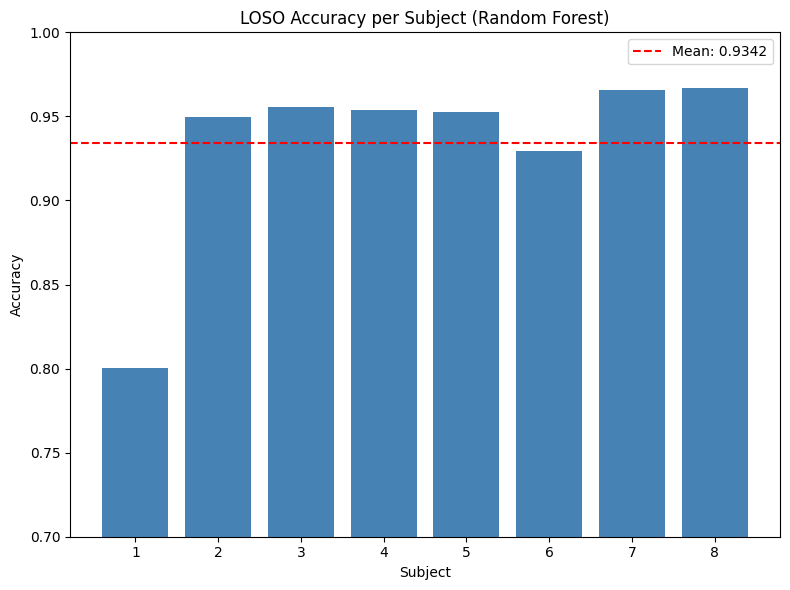

In [10]:
subjects = [1,2,3,4,5,6,7,8]
acc = [0.8006, 0.9494, 0.9556, 0.9540, 0.9529, 0.9292,0.9656, 0.9666]
plt.figure(figsize=(8,6))
plt.bar(subjects, acc, color='steelblue')
plt.axhline(y=np.mean(acc), color='red', linestyle='--', label=f'Mean: {np.mean(acc):.4f}')
plt.xlabel('Subject')
plt.ylabel('Accuracy')
plt.title('LOSO Accuracy per Subject (Random Forest)')
plt.ylim(0.7, 1.0)
plt.legend()
plt.tight_layout()
plt.savefig('loso_accuracy.png', dpi=150)
plt.show()

In [ ]:
# --- Plot Macro F1 Score per subject ---
subjects  = list(results.keys())
macro_f1s = [results[s]['macro_f1'] for s in subjects]

plt.figure(figsize=(8, 6))
plt.bar(subjects, macro_f1s, color='mediumpurple')
plt.axhline(y=np.mean(macro_f1s), color='red', linestyle='--', label=f'Mean F1: {np.mean(macro_f1s):.4f}')

plt.xlabel('Subject')
plt.ylabel('Macro F1-Score')
plt.title('LOSO Macro F1-Score per Subject (Random Forest)')
plt.ylim(0.7, 1.0)
plt.legend()
plt.tight_layout()
plt.savefig('loso_f1_rf.png', dpi=150)
plt.show()

# --- Global Evaluation Metrics ---
# Calculate Macro and Weighted F1 Score globally
macro_f1 = f1_score(global_y_true, global_y_pred, average='macro')
weighted_f1 = f1_score(global_y_true, global_y_pred, average='weighted')

print(f"Global Macro F1-Score:    {macro_f1:.4f}")
print(f"Global Weighted F1-Score: {weighted_f1:.4f}\n")

# Extract unique classes directly from the data for labels
classes = np.unique(global_y_true)
print(classification_report(global_y_true, global_y_pred, target_names=classes.astype(str)))

# --- Plot the Global Confusion Matrix ---
cm = confusion_matrix(global_y_true, global_y_pred)
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes.astype(str))
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)

plt.title('Global LOSO Confusion Matrix (Random Forest)', fontsize=14)
plt.tight_layout()
plt.savefig('global_confusion_matrix_rf.png', dpi=150)
plt.show()